<div style="border: 3px solid #A30000; padding: 15px; border-radius: 12px; background-color: #FFB8B8; text-align: center;">
  <h1 style="color: #A30000;">Partie 1 - Importation et analyse exploiratoire des fichiers</h1>
</div>

<div style="background-color: #A30000; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">1.1 - Importation des librairies</h3>
</div>

In [12]:
#Importation des librairies
import pandas as pd
import numpy as np
import plotly.express as px 

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">1.2 - Chargement des fichiers</h3>
</div>

#### Les données fournis ne contiennent que la disponibilité alimentaire de 2017 et l'évolution de la population de 2000 à 2018. Dans l'optique d'une analyse PESTEL on a besoin de plus d'information afin d'identifier au moins 8 variables pertinentes. Je suis donc aller chercher des données complémentaires et j'ai choisi l'année 2017 en référence pour aller avec les données déjà fournis. 
- Politique : Stabilité politique
- Economique : PIB, population
- Socioculturel : Disponibilité alimentaire, consommation de volaille
- Technologique : Indice LPI (infrastructures logistique)
- Environnement : Production de volaille
- Légal : Indice de liberté économique

In [14]:
#Environnemental : distance avec la france par exemple

In [15]:
#Importation du fichier Population_2000_2018 - source : fichiers fournis
df_pop = pd.read_csv('Population_2000_2018.csv')
#Importation du fichier DisponibiliteAlimentaire_2017 - source : fichiers fournis
df_dispo = pd.read_csv('DisponibiliteAlimentaire_2017.csv')
#Importation du fichier PIB_2017 - source : https://www.fao.org/faostat/en/#data/MK
df_pib = pd.read_csv('PIB_2017.csv')
#Importation du fichier Production_2017 - source : https://www.fao.org/faostat/en/#data/TCL
df_prod = pd.read_csv('Production_2017.csv')
#Importation du fichier Stabilité_2017 - source : https://www.fao.org/faostat/en/#data/FS
df_stabilite = pd.read_csv('Stabilité_2017.csv')
#Importation du fichier Liberte_éco_2017 - source : https://www.heritage.org/index/
df_eco = pd.read_csv('Liberte_éco_2017.csv', skiprows=3)
#Importation du fichier Logistique_2007_2022 - source : https://data.worldbank.org/indicator/LP.LPI.INFR.XQ
df_logi = pd.read_csv('Logistique_2007_2022.csv', skiprows=3)

<div style="background-color: #A30000; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.1 - Analyse exploratoire du fichier Population_2000_2018.xlsx</h3>
</div>

In [16]:
#Afficher les infos du dataset
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

In [17]:
#Afficher les 5 premières lignes de la table
df_pop.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,137,Mauritius,511,Population totale,3010,Population-Estimations,2011,2011,1000 personnes,1251.08,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,74,Gabon,511,Population totale,3010,Population-Estimations,2014,2014,1000 personnes,1883.80,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,227,Tuvalu,511,Population totale,3010,Population-Estimations,2005,2005,1000 personnes,10.00,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,23,Belize,511,Population totale,3010,Population-Estimations,2012,2012,1000 personnes,338.00,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,48,Costa Rica,511,Population totale,3010,Population-Estimations,2012,2012,1000 personnes,4688.00,X,Sources internationales sûres,NaN


In [18]:
#Afficher les valeurs distinctes de la colonne 'Élément' pour s'assurer que l'on a que la population totale
df_pop['Élément'].unique()

array(['Population totale'], dtype=object)

In [19]:
#On se limite uniquement à la population de 2017 avec une copie de df_pop
df_pop_2017 = df_pop[df_pop['Année'] == 2017].copy()

In [20]:
#On garde les colonnes utiles pour l'analyse : Code zone; Zone; Valeur
df_pop_2017 = df_pop_2017[['Zone', 'Valeur']].rename(columns={'Zone': 'Country', 'Valeur': 'Population_2017'})

In [21]:
#Afficher les 5 premières lignes de la table
df_pop_2017.head()

,Country,Population_2017
10,Tokelau,1.300
16,Wallis and Futuna Islands,11.900
20,Botswana,2205.080
31,Slovakia,5447.900
42,Holy See,0.793


In [22]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_pop_2017.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [23]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_pop_2017.isna().sum())

Nombre de valeurs manquantes : Country            0
Population_2017    0
dtype: int64


In [24]:
#Exploration du dataset
df_pop_2017.describe(include = 'all')

,Country,Population_2017
count,236,2.360000e+02
unique,236,NaN
top,Tokelau,NaN
freq,1,NaN
mean,NaN,3.198362e+04
std,NaN,1.318949e+05
min,NaN,7.930000e-01
25%,NaN,3.803032e+02
50%,NaN,5.203511e+03
75%,NaN,1.930842e+04


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.2 - Analyse exploratoire du fichier DisponibiliteAlimentaire_2017.xlsx</h3>
</div>

In [25]:
#Afficher les infos du dataset
df_dispo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

In [26]:
#Afficher les 5 premières lignes de la table
df_dispo.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [27]:
#Afficher les valeurs distinctes des colonnes Élément, Produit, Unité, Année pour filtrer nos besoins
print("Élément :", df_dispo['Élément'].unique()) 
print("Produit :", df_dispo['Produit'].unique())
print("Unité :", df_dispo['Unité'].unique())
print("Année :", df_dispo['Année'].unique())

Élément : ['Production' 'Importations - Quantité' 'Variation de stock'
 'Exportations - Quantité' 'Disponibilité intérieure'
 'Aliments pour animaux' 'Semences' 'Pertes' 'Résidus' 'Nourriture'
 'Disponibilité alimentaire en quantité (kg/personne/an)'
 'Disponibilité alimentaire (Kcal/personne/jour)'
 'Disponibilité de protéines en quantité (g/personne/jour)'
 'Disponibilité de matière grasse en quantité (g/personne/jour)'
 'Traitement' 'Autres utilisations (non alimentaire)'
 'Alimentation pour touristes']
Produit : ['Blé et produits' 'Riz et produits' 'Orge et produits' 'Maïs et produits'
 'Seigle et produits' 'Avoine' 'Millet et produits' 'Sorgho et produits'
 'Céréales, Autres' 'Pommes de Terre et produits' 'Ignames' 'Racines nda'
 'Sucre, canne' 'Sucre, betterave' 'Sucre Eq Brut' 'Edulcorants Autres'
 'Miel' 'Haricots' 'Pois' 'Légumineuses Autres et produits'
 'Noix et produits' 'Soja' 'Arachides Decortiquees' 'Graines de tournesol'
 'Graines Colza/Moutarde' 'Graines de coton' 'Coc

#### Je garde comme produit plusieurs type de viande (volaille, boeuf, porc, ...) pour rajouter dans mes analyses la typologie des marchés selon le type de viande ou encore la concurrence de consommation entre elles.

In [28]:
#Création d'une copie df_dispo avec uniquement les produits utiles à notre analyse 
#Ici Viande de volailles mais aussi les autres type de viande pour comparer les consommations 
viandes = ['Viande de Volailles', 'Viande de Suides', 'Viande de Bovins', 'Viande d\'Ovins/Caprins']
df_viandes = df_dispo[
    (df_dispo['Produit'].isin(viandes)) &
    (df_dispo['Élément'] == 'Disponibilité alimentaire en quantité (kg/personne/an)') &
    (df_dispo['Unité'] == 'kg') &
    (df_dispo['Année'] == 2017)
].copy()

In [29]:
#On garde les colonnes utiles pour l'analyse : Code zone; Zone; Valeur
df_viandes = df_viandes[['Zone', 'Élément', 'Produit', 'Valeur']].rename(columns={'Zone': 'Country'})
#On rend le tableau plus visible
df_viandes = df_viandes.pivot(index=['Country'], columns='Produit', values='Valeur').reset_index()

In [30]:
#Afficher les 5 premières lignes de la table
df_viandes.head()

Produit,Country,Viande d'Ovins/Caprins,Viande de Bovins,Viande de Suides,Viande de Volailles
0,Afghanistan,4.15,2.61,0.00,1.53
1,Albania,9.11,14.67,7.20,16.36
2,Algeria,6.69,4.63,0.00,6.38
3,Angola,0.77,4.33,7.50,10.56
4,Antigua and Barbuda,1.99,7.47,8.22,54.10


In [31]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_viandes.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [32]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_viandes.isna().sum())

Nombre de valeurs manquantes : Produit
Country                   0
Viande d'Ovins/Caprins    0
Viande de Bovins          0
Viande de Suides          3
Viande de Volailles       0
dtype: int64


In [33]:
#Exploration du dataset
df_viandes.describe(include = 'all')

Produit,Country,Viande d'Ovins/Caprins,Viande de Bovins,Viande de Suides,Viande de Volailles
count,172,172.000000,172.000000,169.000000,172.000000
unique,172,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,2.923198,10.294826,14.181479,20.213372
std,NaN,5.328709,8.462553,15.487369,15.860311
min,NaN,0.010000,0.620000,0.000000,0.130000
25%,NaN,0.510000,4.275000,1.310000,6.440000
50%,NaN,1.350000,7.395000,8.580000,18.090000
75%,NaN,2.982500,14.672500,24.460000,30.037500


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.3 - Analyse exploratoire du fichier PIB_2017.csv</h3>
</div>

In [34]:
#Afficher les infos du dataset
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       1260 non-null   object 
 1   Domain            1260 non-null   object 
 2   Area Code (M49)   1260 non-null   int64  
 3   Area              1260 non-null   object 
 4   Element Code      1260 non-null   int64  
 5   Element           1260 non-null   object 
 6   Item Code         1260 non-null   int64  
 7   Item              1260 non-null   object 
 8   Year Code         1260 non-null   int64  
 9   Year              1260 non-null   int64  
 10  Unit              1260 non-null   object 
 11  Value             1260 non-null   float64
 12  Flag              1260 non-null   object 
 13  Flag Description  1260 non-null   object 
 14  Note              0 non-null      float64
dtypes: float64(2), int64(5), object(8)
memory usage: 147.8+ KB


In [35]:
#Afficher les 5 premières lignes de la table
df_pib.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,4,Afghanistan,6110,Value US$,22008,Gross Domestic Product,2017,2017,million USD,19034.302820,X,Figure from external organization,NaN
1,MK,Macro Indicators,4,Afghanistan,6119,Value US$ per capita,22008,Gross Domestic Product,2017,2017,USD,533.339061,X,Figure from external organization,NaN
2,MK,Macro Indicators,4,Afghanistan,6129,Annual growth US$,22008,Gross Domestic Product,2017,2017,%,4.444345,X,Figure from external organization,NaN
3,MK,Macro Indicators,4,Afghanistan,6110,Value US$,22011,Gross National Income,2017,2017,million USD,19245.735750,X,Figure from external organization,NaN
4,MK,Macro Indicators,4,Afghanistan,6119,Value US$ per capita,22011,Gross National Income,2017,2017,USD,539.263388,X,Figure from external organization,NaN


In [36]:
#Afficher les valeurs distinctes des colonnes Element, Item, Unit, Year pour filtrer nos besoins
print("Element :", df_pib['Element'].unique()) 
print("Item :", df_pib['Item'].unique())
print("Unit :", df_pib['Unit'].unique())
print("Year :", df_pib['Year'].unique())

Element : ['Value US$' 'Value US$ per capita' 'Annual growth US$']
Item : ['Gross Domestic Product' 'Gross National Income']
Unit : ['million USD' 'USD' '%']
Year : [2017]


#### Je garde le PIB par habitant (Value USS per capita) mais aussi le taux de croissance du PIB (Annual growth USS) pour mes analyses. Pour le PIB total je ne le garde pas pour réduire le dataset final mais il peut toujours être calculé avec la population x PIB/hab. Et pour les Item je garde seulement le PIB (Gross Domestic Product).

In [37]:
#Création d'un copie de df_pib avec uniquement le PIB et les éléments qui sont utiles pour l'analyse
df_pib_2017 = df_pib[(df_pib['Item'] == 'Gross Domestic Product') &
                     (df_pib['Element'] != 'Value US$')].copy()
#On rend le tableau plus visible
df_pib_2017 = df_pib_2017.pivot(index=['Area'],
                                 columns='Element',
                                 values='Value').reset_index()
#On renomme les colonne pour plus de visibilité
df_pib_2017 = df_pib_2017.rename(columns={
    'Area': 'Country',
    'Value US$ per capita': 'PIB/hab_2017_USD',
    'Annual growth US$': 'PIB_croissance_2017'})

In [39]:
#Afficher les 5 premières lignes de la table
df_pib_2017.head()

Element,Country,PIB_croissance_2017,PIB/hab_2017_USD
0,Afghanistan,4.444345,533.339061
1,Albania,9.767331,4492.285003
2,Algeria,6.287893,4080.111475
3,Andorra,3.574787,40673.244876
4,Angola,20.766649,4039.176725


In [40]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_pib_2017.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [41]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_pib_2017.isna().sum())

Nombre de valeurs manquantes : Element
Country                0
PIB_croissance_2017    0
PIB/hab_2017_USD       0
dtype: int64


In [42]:
#Exploration du dataset
df_pib_2017.describe(include = 'all')

Element,Country,PIB_croissance_2017,PIB/hab_2017_USD
count,210,210.000000,210.000000
unique,210,NaN,NaN
top,Afghanistan,NaN,NaN
freq,1,NaN,NaN
mean,NaN,7.212668,16972.372144
std,NaN,7.415465,25487.585582
min,NaN,-27.928307,286.599032
25%,NaN,4.505899,2045.622133
50%,NaN,7.251468,6329.403658
75%,NaN,9.916203,20688.698897


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.4 - Analyse exploratoire du fichier Production_2017.csv</h3>
</div>

In [43]:
#Afficher les infos du dataset
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       4439 non-null   object 
 1   Domain            4439 non-null   object 
 2   Area Code (M49)   4439 non-null   int64  
 3   Area              4439 non-null   object 
 4   Element Code      4439 non-null   int64  
 5   Element           4439 non-null   object 
 6   Item Code (CPC)   4439 non-null   float64
 7   Item              4439 non-null   object 
 8   Year Code         4439 non-null   int64  
 9   Year              4439 non-null   int64  
 10  Unit              4439 non-null   object 
 11  Value             4439 non-null   int64  
 12  Flag              4439 non-null   object 
 13  Flag Description  4439 non-null   object 
 14  Note              427 non-null    object 
dtypes: float64(1), int64(5), object(9)
memory usage: 520.3+ KB


In [44]:
#Afficher les 5 premières lignes de la table
df_prod.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5608,Import quantity,2111.0,Cattle,2017,2017,An,26992,A,Official figure,NaN
1,TCL,Crops and livestock products,4,Afghanistan,5622,Import value,2111.0,Cattle,2017,2017,1000 USD,10535,A,Official figure,NaN
2,TCL,Crops and livestock products,4,Afghanistan,5609,Import quantity,2151.0,Chickens,2017,2017,1000 An,18970,A,Official figure,NaN
3,TCL,Crops and livestock products,4,Afghanistan,5622,Import value,2151.0,Chickens,2017,2017,1000 USD,26227,A,Official figure,NaN
4,TCL,Crops and livestock products,4,Afghanistan,5608,Import quantity,2131.0,Horses,2017,2017,An,12112,A,Official figure,NaN


In [45]:
#Afficher les valeurs distinctes des colonnes Element, Item, Unit, Year pour filtrer nos besoins
print("Element :", df_prod['Element'].unique()) 
print("Item :", df_prod['Item'].unique())
print("Unit :", df_prod['Unit'].unique())
print("Year :", df_prod['Year'].unique())

Element : ['Import quantity' 'Import value' 'Export quantity' 'Export value']
Item : ['Cattle' 'Chickens' 'Horses' 'Sheep' 'Geese' 'Swine / pigs' 'Turkeys'
 'Ducks' 'Goats' 'Mules and hinnies' 'Other live animals non food, n.e.c.'
 'Other live animals, n.e.c.' 'Other rodents' 'Rabbits and hares' 'Asses'
 'Buffalo' 'Camels' 'Other camelids']
Unit : ['An' '1000 USD' '1000 An']
Year : [2017]


#### Ici on parle d'animaux vivant pour la production donc ils ne sont pas directement liés à la concommation de viande. Du coup je vais garder comme Item seulement 'Chickens'.

In [46]:
#On garde uniquement la production de poulet
df_prod_2017 = df_prod[df_prod['Item'] == 'Chickens'].copy()
#On garde uniquement les colonnes utiles 
df_prod_2017 = df_prod_2017[['Area', 'Element', 'Unit', 'Value']]

In [47]:
#Vérification des unités
print(df_prod_2017['Unit'].value_counts())

Unit
1000 An     287
1000 USD    287
Name: count, dtype: int64


#### Les valeurs sont soit en 1000 AN (quantités en milliers de têtes) et 1000 USD (valeurs monétaire en milliers de dollars). Je vais garder une seule unité, 1000 AN pour avoir un indicateur de production/commercialisation physique.

In [48]:
#On garde l'unité 1000 AN
df_prod_2017 = df_prod_2017[df_prod_2017['Unit'] == '1000 An']

In [49]:
#On rend le tableau plus lisible
df_prod_2017 = df_prod_2017.pivot(index=['Area'],
                                      columns='Element',
                                      values='Value').reset_index()

#On renomme les colonnes pour plus de lisibilité
df_prod_2017 = df_prod_2017.rename(columns={
    'Area': 'Country',
    'Import quantity': 'Import_Poulet_1000AN',
    'Export quantity': 'Export_Poulet_1000AN'})

#### On en profite pour créer une colonne solde commercial (exportation - importation) qui nous sera utile après pour les analyses.

In [50]:
#Création colonne solde commercial
df_prod_2017['SC_Poulet_1000AN'] = (df_prod_2017['Export_Poulet_1000AN']-df_prod_2017['Import_Poulet_1000AN'])

In [51]:
#Afficher les 5 premières lignes de la table
df_prod_2017.head()

Element,Country,Export_Poulet_1000AN,Import_Poulet_1000AN,SC_Poulet_1000AN
0,Afghanistan,NaN,18970.0,NaN
1,Albania,NaN,4572.0,NaN
2,Algeria,NaN,195.0,NaN
3,Angola,NaN,1649.0,NaN
4,Antigua and Barbuda,2.0,10.0,-8.0


In [52]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_prod_2017.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [54]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_prod_2017.isna().sum())

Nombre de valeurs manquantes : Element
Country                  0
Export_Poulet_1000AN    83
Import_Poulet_1000AN     4
SC_Poulet_1000AN        87
dtype: int64


In [55]:
#Exploration du dataset
df_prod_2017.describe(include = 'all')

Element,Country,Export_Poulet_1000AN,Import_Poulet_1000AN,SC_Poulet_1000AN
count,187,104.000000,183.000000,100.000000
unique,187,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,17361.394231,10036.491803,1535.580000
std,NaN,51492.753803,40989.541717,30306.756116
min,NaN,0.000000,0.000000,-119514.000000
25%,NaN,34.750000,116.500000,-2829.750000
50%,NaN,482.000000,820.000000,-259.500000
75%,NaN,8255.000000,3255.000000,803.000000


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.5 - Analyse exploratoire du fichier Stabilité_2017.csv</h3>
</div>

In [56]:
#Afficher les infos du dataset
df_stabilite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       747 non-null    object 
 1   Domain            747 non-null    object 
 2   Area Code (M49)   747 non-null    int64  
 3   Area              747 non-null    object 
 4   Element Code      747 non-null    int64  
 5   Element           747 non-null    object 
 6   Item Code         747 non-null    int64  
 7   Item              747 non-null    object 
 8   Year Code         747 non-null    int64  
 9   Year              747 non-null    object 
 10  Unit              552 non-null    object 
 11  Value             747 non-null    float64
 12  Flag              747 non-null    object 
 13  Flag Description  747 non-null    object 
 14  Note              0 non-null      float64
dtypes: float64(2), int64(4), object(9)
memory usage: 87.7+ KB


In [57]:
#Afficher les 5 premières lignes de la table
df_stabilite.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,FS,Suite of Food Security Indicators,4,Afghanistan,6123,Value,21013,Average protein supply (g/cap/day) (3-year ave...,20162018,2016-2018,g/cap/d,64.40,E,Estimated value,NaN
1,FS,Suite of Food Security Indicators,4,Afghanistan,6123,Value,21014,Average supply of protein of animal origin (g/...,20162018,2016-2018,g/cap/d,11.70,E,Estimated value,NaN
2,FS,Suite of Food Security Indicators,4,Afghanistan,6126,Value,22013,"Gross domestic product per capita, PPP, (const...",2017,2017,Int$/cap,2953.00,X,Figure from external organization,NaN
3,FS,Suite of Food Security Indicators,4,Afghanistan,6125,Value,21032,Political stability and absence of violence/te...,2017,2017,NaN,-2.79,X,Figure from external organization,NaN
4,FS,Suite of Food Security Indicators,8,Albania,6123,Value,21013,Average protein supply (g/cap/day) (3-year ave...,20162018,2016-2018,g/cap/d,116.30,E,Estimated value,NaN


In [58]:
#Afficher les valeurs distinctes des colonnes Element, Item, Unit, Year pour filtrer nos besoins
print("Element :", df_stabilite['Element'].unique()) 
print("Item :", df_stabilite['Item'].unique())
print("Unit :", df_stabilite['Unit'].unique())
print("Year :", df_stabilite['Year'].unique())

Element : ['Value']
Item : ['Average protein supply (g/cap/day) (3-year average)'
 'Average supply of protein of animal origin (g/cap/day) (3-year average)'
 'Gross domestic product per capita, PPP, (constant 2021 international $)'
 'Political stability and absence of violence/terrorism (index)']
Unit : ['g/cap/d' 'Int$/cap' nan]
Year : ['2016-2018' '2017']


#### On a une seule valeur dans Element et Unit donc pas besoin de toucher à cela. 
#### Pour l'analyse des items on va garder celles utiles et les renommer pour plus de visibilité du tableau
- Average protein supply (g/cap/day) (3-year average) : apport protéines/habitant (g/jour)
- Average supply of protein of animal origin (g/cap/day) (3-year average) : Apport moyen en protéines animales/habitant (g/jour)
- Gross domestic product per capita, PPP, (constant 2021 international $) : PIB par habitant en parité de pouvoir d’achat (on a déjà un indicateur PIB, pas utile)
- Political stability and absence of violence/terrorism (index) : Indicateur de la Banque mondiale (de -2.5 = très instable → +2.5 = très stable)
#### Pour les années, les valeurs de nutrition sont une moyennes sur 3 ans et pour la stabilité politique l'année exacte : 2017

In [59]:
#On garde seulement les colonnes utiles
df_stab = df_stabilite[df_stabilite['Item'] != 'Gross domestic product per capita, PPP, (constant 2021 international $)']
[['Area', 'Item', 'Value']].copy()
#On rend le tableau plus lisible
df_stab = df_stab.pivot(index=['Area'],
                        columns='Item',
                        values='Value').reset_index()
#Renommer les colonnes pour plus de lisibilité
df_stab = df_stab.rename(columns={
    'Area': 'Country',
    'Average protein supply (g/cap/day) (3-year average)': 'Prot_hab_g/j',
    'Average supply of protein of animal origin (g/cap/day) (3-year average)': 'Prot_Anim_hab_g/j',
    'Political stability and absence of violence/terrorism (index)': 'Pol_Stab_2017'})

In [60]:
#Afficher les 5 premières lignes de la table
df_stab.head()

Item,Country,Prot_hab_g/j,Prot_Anim_hab_g/j,Pol_Stab_2017
0,Afghanistan,64.4,11.7,-2.79
1,Albania,116.3,63.9,0.37
2,Algeria,93.6,28.8,-0.92
3,American Samoa,NaN,NaN,1.18
4,Andorra,NaN,NaN,1.39


In [61]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_stab.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [62]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_stab.isna().sum())

Nombre de valeurs manquantes : Item
Country               0
Prot_hab_g/j         20
Prot_Anim_hab_g/j    20
Pol_Stab_2017         6
dtype: int64


In [63]:
#Exploration du dataset
df_stab.describe(include = 'all')

Item,Country,Prot_hab_g/j,Prot_Anim_hab_g/j,Pol_Stab_2017
count,201,181.000000,181.000000,195.000000
unique,201,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,86.658564,41.266298,-0.068615
std,NaN,22.890105,22.318936,0.995046
min,NaN,30.300000,2.900000,-2.930000
25%,NaN,67.100000,21.300000,-0.660000
50%,NaN,89.400000,39.600000,0.030000
75%,NaN,104.800000,59.700000,0.765000


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.6 - Analyse exploratoire du fichier Liberte_éco_2017.csv</h3>
</div>

In [64]:
#Afficher les infos du dataset
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 186 non-null    object 
 1   Index Year              186 non-null    int64  
 2   Overall Score           180 non-null    float64
 3   Property Rights         185 non-null    float64
 4   Government Integrity    185 non-null    float64
 5   Judicial Effectiveness  184 non-null    float64
 6   Tax Burden              182 non-null    float64
 7   Government Spending     183 non-null    float64
 8   Fiscal Health           185 non-null    float64
 9   Business Freedom        186 non-null    float64
 10  Labor Freedom           186 non-null    float64
 11  Monetary Freedom        183 non-null    float64
 12  Trade Freedom           183 non-null    float64
 13  Investment Freedom      181 non-null    float64
 14  Financial Freedom       181 non-null    fl

In [65]:
#Afficher les 5 premières lignes de la table
df_eco.head()

,Country,Index Year,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,Afghanistan,2017,48.9,12.6,27.5,28.4,91.6,79.9,97.3,54.2,59.9,69.3,66.0,0.0,0.0
1,Albania,2017,64.4,54.0,39.7,28.5,86.9,72.5,51.5,79.3,50.7,81.4,87.7,70.0,70.0
2,Algeria,2017,46.5,38.2,31.7,29.6,81.1,51.0,19.8,62.1,49.5,67.0,63.3,35.0,30.0
3,Angola,2017,48.5,36.4,12.8,19.8,87.7,58.6,70.7,58.5,40.4,70.6,56.7,30.0,40.0
4,Argentina,2017,50.4,32.4,38.2,39.6,62.6,54.6,56.4,57.3,46.1,50.9,66.7,50.0,50.0


In [66]:
#Afficher les valeurs distinctes de la colonne Index Year pour filtrer nos besoins
print("Index Year :", df_eco['Index Year'].unique()) 

Index Year : [2017]


In [67]:
#On garde seulement le score global
df_eco_2017 = df_eco[['Country','Overall Score']].copy()
df_eco_2017 = df_eco_2017.rename(columns={'Overall Score':'Eco_Lib_Score'})

In [68]:
#Afficher les 5 premières lignes de la table
df_eco_2017.head()

,Country,Eco_Lib_Score
0,Afghanistan,48.9
1,Albania,64.4
2,Algeria,46.5
3,Angola,48.5
4,Argentina,50.4


In [69]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_eco_2017.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [70]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_eco_2017.isna().sum())

Nombre de valeurs manquantes : Country          0
Eco_Lib_Score    6
dtype: int64


In [71]:
#Exploration du dataset
df_eco_2017.describe(include = 'all')

,Country,Eco_Lib_Score
count,186,180.000000
unique,186,NaN
top,Afghanistan,NaN
freq,1,NaN
mean,NaN,60.902222
std,NaN,10.956791
min,NaN,4.900000
25%,NaN,53.475000
50%,NaN,61.000000
75%,NaN,68.000000


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">2.7 - Analyse exploratoire du fichier Logistique_2007_2022.csv</h3>
</div>

In [72]:
#Afficher les infos du dataset
df_logi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [73]:
#Afficher les 5 premières lignes de la table
df_logi.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Logistics performance index: Quality of trade ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Logistics performance index: Quality of trade ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.392239,NaN,2.237778,NaN,NaN,NaN,2.518182,NaN,NaN,NaN
2,Afghanistan,AFG,Logistics performance index: Quality of trade ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,1.835473,NaN,1.810000,NaN,NaN,NaN,1.700000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Logistics performance index: Quality of trade ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.177056,NaN,2.172857,NaN,NaN,NaN,2.293333,NaN,NaN,NaN
4,Angola,AGO,Logistics performance index: Quality of trade ...,LP.LPI.INFR.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.133789,NaN,1.860000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN


In [74]:
#Afficher les valeurs distinctes de la colonne Index Year pour filtrer nos besoins
print("Indicator Name :", df_logi['Indicator Name'].unique()) 

Indicator Name : ['Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)']


#### On remarque qu'il n'y a pas eu d'enquête pour l'année 2017., je vais donc prendre les années 2016 2018 et lisser pour avoir une valeur interpolée pour 2017.

In [75]:
#On garde uniquement les colonnes Country Name, 2016 et 2018
df_logi_2017 = df_logi[['Country Name','2016','2018']].copy()

In [76]:
#On créer la valeur lissée (moyenne simple)
df_logi_2017['LPI_2017'] = df_logi_2017[['2016','2018']].mean(axis=1)

In [77]:
#On renomme la colonne Country Name comme les autres datasets
df_logi_2017 = df_logi_2017.rename(columns={'Country Name':'Country'})

In [78]:
#On garde que les colonnes country et LPI_2017
df_logi_2017 = df_logi_2017[['Country','LPI_2017']]

In [79]:
#Afficher les 5 premières lignes de la table
df_logi_2017.head()

,Country,LPI_2017
0,Aruba,NaN
1,Africa Eastern and Southern,2.315008
2,Afghanistan,1.822736
3,Africa Western and Central,2.174957
4,Angola,1.996895


In [80]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_logi_2017.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [81]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_logi_2017.isna().sum())

Nombre de valeurs manquantes : Country      0
LPI_2017    53
dtype: int64


In [82]:
#Exploration du dataset
df_logi_2017.describe(include = 'all')

,Country,LPI_2017
count,266,213.000000
unique,266,NaN
top,Zimbabwe,NaN
freq,1,NaN
mean,NaN,2.692712
std,NaN,0.634384
min,NaN,1.690000
25%,NaN,2.228333
50%,NaN,2.498659
75%,NaN,3.106358


<div style="background-color: #A30000; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jointure des tables</h2>
</div>

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">3.1 - Vérification et harmonisation de la clé Country avant fusion</h3>
</div>

In [83]:
#Vérification des doublons dans la colonne Country pour chaque dataset
print("Nombre Country en doublon dans df_pop_2017 : {}".format(df_pop_2017['Country'].isna().sum()))
print("Nombre Country en doublon dans df_viandes : {}".format(df_viandes['Country'].isna().sum()))
print("Nombre Country en doublon dans df_pib_2017 : {}".format(df_pib_2017['Country'].isna().sum()))
print("Nombre Country en doublon dans df_prod_2017 : {}".format(df_prod_2017['Country'].isna().sum()))
print("Nombre Country en doublon dans df_stab : {}".format(df_stab['Country'].isna().sum()))
print("Nombre Country en doublon dans df_eco_2017 : {}".format(df_eco_2017['Country'].isna().sum()))
print("Nombre Country en doublon dans df_logi_2017 : {}".format(df_logi_2017['Country'].isna().sum()))

Nombre Country en doublon dans df_pop_2017 : 0
Nombre Country en doublon dans df_viandes : 0
Nombre Country en doublon dans df_pib_2017 : 0
Nombre Country en doublon dans df_prod_2017 : 0
Nombre Country en doublon dans df_stab : 0
Nombre Country en doublon dans df_eco_2017 : 0
Nombre Country en doublon dans df_logi_2017 : 0


In [84]:
#Vérification du nombre de pays unique dans la colonne Country pour chaque dataset
print("Nombre de Country unique dans df_pop_2017 : {}".format(df_pop_2017['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_viandes : {}".format(df_viandes['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_pib_2017 : {}".format(df_pib_2017['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_prod_2017 : {}".format(df_prod_2017['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_stab : {}".format(df_stab['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_eco_2017 : {}".format(df_eco_2017['Country'].nunique(), "pays"))
print("Nombre de Country unique dans df_logi_2017 : {}".format(df_logi_2017['Country'].nunique(), "pays"))

Nombre de Country unique dans df_pop_2017 : 236
Nombre de Country unique dans df_viandes : 172
Nombre de Country unique dans df_pib_2017 : 210
Nombre de Country unique dans df_prod_2017 : 187
Nombre de Country unique dans df_stab : 201
Nombre de Country unique dans df_eco_2017 : 186
Nombre de Country unique dans df_logi_2017 : 266


#### L'échantillon final ne pourra donc pas dépasser 172 pays (df_viandes est le plus restricitif) mais on couvre toujours plus de 100 pays différents et ils devraient couvrir plus de 60% de la population. On fera une vérification plus tard. Pour l'instant on doit vérifier si le nom des pays correspondent bien entre les différentes bases de données : FAO / Banque mondiale / Heritage.

In [85]:
set_pop = set(df_pop_2017['Country'])
set_viandes = set(df_viandes['Country'])
set_pib = set(df_pib_2017['Country'])
set_prod = set(df_prod_2017['Country'])
set_stab = set(df_stab['Country'])
set_eco = set(df_eco_2017['Country'])
set_logi = set(df_logi_2017['Country'])

diff_viandes = set_viandes - set_pop
print("Pays présents dans viandes mais pas dans pop :", len(diff_viandes))
print(list(diff_viandes))
diff_pib = set_pib - set_pop
print("Pays présents dans pib mais pas dans pop :", len(diff_pib))
print(list(diff_pib))
diff_prod = set_prod - set_pop
print("Pays présents dans prod mais pas dans pop :", len(diff_prod))
print(list(diff_prod))
diff_stab = set_stab - set_pop
print("Pays présents dans stab mais pas dans pop :", len(diff_stab))
print(list(diff_stab))
diff_eco = set_viandes - set_pop
print("Pays présents dans eco mais pas dans pop :", len(diff_eco))
print(list(diff_eco))
diff_logi = set_logi - set_pop
print("Pays présents dans logi mais pas dans pop :", len(diff_logi))
print(list(diff_logi))

Pays présents dans viandes mais pas dans pop : 0
[]
Pays présents dans pib mais pas dans pop : 13
['Grenada', 'Sweden', 'Switzerland', 'Curaçao', "Côte d'Ivoire", 'Viet Nam', 'Czechia', 'Dominica', 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR', 'Benin']
Pays présents dans prod mais pas dans pop : 13
['Grenada', 'Sweden', 'China', 'Switzerland', "Côte d'Ivoire", 'Viet Nam', 'Czechia', 'Dominica', 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR', 'Benin']
Pays présents dans stab mais pas dans pop : 13
['Grenada', 'Sweden', 'China', 'Switzerland', "Côte d'Ivoire", 'Viet Nam', 'Czechia', 'Dominica', 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR', 'Benin']
Pays présents dans eco mais pas dans pop : 0
[]
Pays présents dans logi mais pas dans pop : 89
['Pacific island small states', 'St. Martin (French pa

In [86]:
#Liste des valeurs unique 'Country' dans df_pop_2017
df_pop_2017['Country'].unique()

array(['Tokelau', 'Wallis and Futuna Islands', 'Botswana', 'Slovakia',
       'Holy See', 'Niue', 'Nauru', 'Tonga', 'Portugal',
       'United States Virgin Islands', 'Aruba', 'Dominican Republic',
       'Philippines', 'Greece', 'Ethiopia', 'Czech Republic', 'Burundi',
       'Saint Vincent and the Grenadines', 'South Sudan', 'Haiti',
       'Tuvalu', 'Grenade', 'Micronesia (Federated States of)', 'Benign',
       'Bolivia (Plurinational State of)', 'Eswatini', 'Cuba', 'Kiribati',
       'Belgium', 'Tunisia', 'Cyprus', 'Rwanda', 'Guinea', 'Timor-Leste',
       'Mexico', 'Equatorial Guinea', 'Mauritius', 'Japan', 'Estonia',
       'India', 'Trinidad and Tobago', 'Anguilla', 'China, mainland',
       'Zimbabwe', 'Russian Federation', 'Somalia', 'Bahrain', 'Chad',
       'Senegal', 'Bangladesh', 'Cambodia', 'Curacao', 'Guam', 'Ecuador',
       'Channel Islands', 'Zambia', 'Guatemala', 'Cook Islands', 'Palau',
       'The Netherlands', 'Syrian Arab Republic', 'Malawi', 'Saint Lucia',
    

In [87]:
#Corrections des noms de pays pour harmoniser avec df_pop_2017
country_corrections = {
    "Côte D'Ivoire": "Ivory Coast",
    "Cote D'Ivoire": "Ivory Coast",
    "Benin": "Benign",
    "Sweden": "Suede",
    "Switzerland": "Swiss",
    "Grenada": "Grenade",
    "Dominica": "Dominique",
    "Netherlands": "The Netherlands",
    "Netherlands (Kingdom Of The)": "The Netherlands",
    "Czechia": "Czech Republic",
    "Viet Nam": "Vietnam",
    "Turkey": "Türkiye",
    "Turkiye": "Türkiye",
    "Iran, Islamic Rep.": "Iran (Islamic Republic Of)",
    "Iran": "Iran (Islamic Republic Of)",
    "Democratic Republic Of The Congo": "Democratic Republic Of Congo",
    "Congo, Dem. Rep.": "Democratic Republic Of Congo",
    "Congo, Rep.": "Congo",
    "China, Mainland": "China, Mainland",
    "China": "China, Mainland",
    "China, Macao Sar": "China - Macao Sar",
    "Macao Sar, China": "China - Macao Sar",
    "China, Hong Kong Sar": "China - Hong Kong Sar",
    "Hong Kong Sar, China": "China - Hong Kong Sar",
    "Hong Kong": "China - Hong Kong Sar",
    "Macao": "China - Macao Sar",
    "Korea, Rep.": "Republic Of Korea",
    "Korea, Dem. People'S Rep.": "Democratic People's Republic Of Korea",
    "North Korea": "Democratic People's Republic Of Korea",
    "South Korea": "Republic Of Korea",
    "Republic Of Moldova": "Republic Of Moldova",
    "Moldova": "Republic Of Moldova",
    "Slovak Republic": "Slovakia",
    "Curaçao": "Curacao",
    "Saint Kitts And Nevis": "Saint Kitts And Nevis",
    "St. Kitts And Nevis": "Saint Kitts And Nevis",
    "Saint Lucia": "Saint Lucia",
    "St. Lucia": "Saint Lucia",
    "Saint Vincent And The Grenadines": "Saint Vincent And The Grenadines",
    "St. Vincent And The Grenadines": "Saint Vincent And The Grenadines",
    "Bahamas, The": "Bahamas",
    "Gambia, The": "Gambia",
    "Lao Pdr": "Lao People's Democratic Republic",
    "Micronesia, Fed. Sts.": "Micronesia (Federated States Of)",
    "Egypt, Arab Rep.": "Egypt",
    "Venezuela, Rb": "Venezuela (Bolivarian Republic Of)",
    'United States': 'United States Of America',
    'United Kingdom': 'United Kingdom Of Great Britain And Northern Ireland',
    'Russia': 'Russian Federation',
    'Bolivia': 'Bolivia (Plurinational State Of)',
    'Macau': 'China - Macao Sar',
    'Taiwan': 'China, Taiwan Province Of',
    'Republic Of Congo': 'Congo',
    'Tanzania': 'United Republic Of Tanzania',
    'The Gambia': 'Gambia',
    'The Bahamas': 'Bahamas',
    'Laos': "Lao People's Democratic Republic",
    'Micronesia': 'Micronesia (Federated States Of)',
    'Syria': 'Syrian Arab Republic',
    'São Tomé And Príncipe': 'Sao Tome And Principe',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Burma': 'Myanmar'}

In [88]:
#Normalisation des espaces et capitalisation
for df in [df_viandes, df_pib_2017, df_prod_2017, df_stab, df_eco_2017, df_logi_2017]:
    df['Country'] = df['Country'].str.strip().str.replace(r'\s+', ' ', regex=True)
#Application du dictionnaire de corrections
for df in [df_pib_2017, df_prod_2017, df_stab, df_logi_2017, df_eco_2017]:
    df['Country'] = df['Country'].replace(country_corrections)

#Suppression des zones régionales et agrégats dans df_logi_2017
pattern = ("World|Income|Region|Area|States|Union|OECD|Sub-Saharan|Caribbean|Europe|"
           "Pacific|Asia|Africa|Demographic|IDA|IBRD|Dividend|Total|Other|Members|Small|Blend|Classified")
df_logi_2017 = df_logi_2017[
    ~df_logi_2017['Country'].str.contains(pattern, case=False, na=False)]

#Vérification finale
for name, df in zip(
    ['viandes','pib','prod','stab','eco','logi'],
    [df_viandes, df_pib_2017, df_prod_2017, df_stab, df_eco_2017, df_logi_2017]):
    diff = set(df['Country']) - set(df_pop_2017['Country'])
    print(f"{name} → {len(diff)} pays non trouvés :", diff)

viandes → 0 pays non trouvés : set()
pib → 5 pays non trouvés : {"Côte d'Ivoire", 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR'}
prod → 6 pays non trouvés : {"Côte d'Ivoire", 'China, Mainland', 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR'}
stab → 6 pays non trouvés : {"Côte d'Ivoire", 'China, Mainland', 'China, Macao SAR', 'Democratic Republic of the Congo', 'Netherlands (Kingdom of the)', 'China, Hong Kong SAR'}
eco → 19 pays non trouvés : {'Iran (Islamic Republic Of)', 'The Philippines', 'Kosovo', 'United Republic Of Tanzania', 'Micronesia (Federated States Of)', 'Bolivia (Plurinational State Of)', 'United Kingdom Of Great Britain And Northern Ireland', 'Republic of Congo', 'São Tomé and Príncipe', 'Venezuela', 'China, Taiwan Province Of', "Côte d'Ivoire", 'China, Mainland', 'China - Hong Kong Sar', 'United States Of America', 'Republic Of Moldova', "Demo

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">3.2 - Fusion des données fao</h3>
</div>

In [89]:
df_fao_1 = pd.merge(df_pop_2017, df_viandes, on = 'Country', how='inner')

In [90]:
df_fao_2 = pd.merge(df_fao_1, df_pib_2017, on = 'Country', how='inner')

In [91]:
df_fao_3 = pd.merge(df_fao_2, df_prod_2017, on = 'Country', how='inner')

In [92]:
df_fao = pd.merge(df_fao_3, df_stab, on = 'Country', how='inner')

In [93]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_fao.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [94]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_fao.isna().sum())

Nombre de valeurs manquantes : Country                    0
Population_2017            0
Viande d'Ovins/Caprins     0
Viande de Bovins           0
Viande de Suides           3
Viande de Volailles        0
PIB_croissance_2017        0
PIB/hab_2017_USD           0
Export_Poulet_1000AN      63
Import_Poulet_1000AN       4
SC_Poulet_1000AN          67
Prot_hab_g/j               0
Prot_Anim_hab_g/j          0
Pol_Stab_2017              4
dtype: int64


In [95]:
#Exploration du dataset
df_fao.describe(include = 'all')

,Country,Population_2017,Viande d'Ovins/Caprins,Viande de Bovins,Viande de Suides,Viande de Volailles,PIB_croissance_2017,PIB/hab_2017_USD,Export_Poulet_1000AN,Import_Poulet_1000AN,SC_Poulet_1000AN,Prot_hab_g/j,Prot_Anim_hab_g/j,Pol_Stab_2017
count,161,1.610000e+02,161.000000,161.000000,158.000000,161.000000,161.000000,161.000000,98.000000,157.000000,94.000000,161.000000,161.000000,157.000000
unique,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Botswana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.507405e+04,2.916894,10.441056,13.601456,20.200559,7.640090,13289.274051,14787.173469,8048.203822,2939.414894,86.965839,41.381988,-0.105732
std,NaN,1.579673e+05,5.271202,8.564715,14.923993,15.852587,7.032683,18111.050283,40315.655347,23455.118132,28599.423671,21.363497,21.096765,0.891884
min,NaN,5.204500e+01,0.010000,0.620000,0.000000,0.130000,-27.928307,432.324071,0.000000,1.000000,-86150.000000,41.500000,6.600000,-2.930000
25%,NaN,2.944791e+03,0.510000,4.330000,1.217500,7.060000,5.199100,1951.066232,41.000000,161.000000,-3015.250000,70.100000,22.900000,-0.640000
50%,NaN,9.785843e+03,1.380000,7.470000,8.105000,17.620000,7.560848,6049.521185,513.500000,991.000000,-253.500000,89.600000,39.600000,-0.050000
75%,NaN,3.195978e+04,3.080000,14.670000,23.857500,29.330000,9.958317,16879.282337,9037.000000,3745.000000,1176.500000,104.500000,59.800000,0.600000


<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">3.3 - Fusion finale</h3>
</div>

In [96]:
df_inter = pd.merge(df_fao, df_eco_2017, on = 'Country', how='inner')

In [97]:
df_lapoule = pd.merge(df_inter, df_logi_2017, on = 'Country', how='inner')

In [98]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_lapoule.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [99]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_lapoule.isna().sum())

Nombre de valeurs manquantes : Country                    0
Population_2017            0
Viande d'Ovins/Caprins     0
Viande de Bovins           0
Viande de Suides           3
Viande de Volailles        0
PIB_croissance_2017        0
PIB/hab_2017_USD           0
Export_Poulet_1000AN      50
Import_Poulet_1000AN       3
SC_Poulet_1000AN          53
Prot_hab_g/j               0
Prot_Anim_hab_g/j          0
Pol_Stab_2017              1
Eco_Lib_Score              1
LPI_2017                  11
dtype: int64


In [100]:
#Exploration du dataset
df_lapoule.describe(include = 'all')

,Country,Population_2017,Viande d'Ovins/Caprins,Viande de Bovins,Viande de Suides,Viande de Volailles,PIB_croissance_2017,PIB/hab_2017_USD,Export_Poulet_1000AN,Import_Poulet_1000AN,SC_Poulet_1000AN,Prot_hab_g/j,Prot_Anim_hab_g/j,Pol_Stab_2017,Eco_Lib_Score,LPI_2017
count,138,1.380000e+02,138.000000,138.000000,135.000000,138.000000,138.000000,138.000000,88.000000,135.000000,85.000000,138.000000,138.000000,137.000000,137.000000,127.000000
unique,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Botswana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.625951e+04,3.096522,10.315507,13.791333,18.572464,7.903282,13282.723283,14966.579545,8910.674074,2324.670588,87.243478,41.107246,-0.083358,61.544526,2.740394
std,NaN,1.202345e+05,5.643156,8.534999,15.502514,14.482558,7.073267,18596.740311,41946.478719,24977.511213,29063.454773,21.357564,21.329321,0.876015,8.977324,0.643780
min,NaN,7.145800e+01,0.010000,0.620000,0.000000,0.130000,-27.928307,470.938555,0.000000,1.000000,-86150.000000,41.500000,6.600000,-2.790000,44.000000,1.705646
25%,NaN,3.372804e+03,0.520000,4.292500,1.015000,5.892500,5.631252,1889.786171,41.000000,213.500000,-3108.000000,70.100000,22.675000,-0.640000,54.400000,2.253167
50%,NaN,9.815582e+03,1.380000,7.395000,7.500000,16.650000,7.729687,5827.666058,487.500000,1091.000000,-294.000000,89.700000,39.450000,-0.050000,61.100000,2.549256
75%,NaN,3.078268e+04,3.122500,14.127500,24.465000,27.777500,10.300621,15540.827541,8255.000000,4015.500000,723.000000,105.175000,59.775000,0.600000,67.900000,3.135005


In [101]:
df_lapoule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 138 non-null    object 
 1   Population_2017         138 non-null    float64
 2   Viande d'Ovins/Caprins  138 non-null    float64
 3   Viande de Bovins        138 non-null    float64
 4   Viande de Suides        135 non-null    float64
 5   Viande de Volailles     138 non-null    float64
 6   PIB_croissance_2017     138 non-null    float64
 7   PIB/hab_2017_USD        138 non-null    float64
 8   Export_Poulet_1000AN    88 non-null     float64
 9   Import_Poulet_1000AN    135 non-null    float64
 10  SC_Poulet_1000AN        85 non-null     float64
 11  Prot_hab_g/j            138 non-null    float64
 12  Prot_Anim_hab_g/j       138 non-null    float64
 13  Pol_Stab_2017           137 non-null    float64
 14  Eco_Lib_Score           137 non-null    fl

<div style="background-color: #A30000; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Amélioration et exploration de la table finale</h2>
</div>

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">4.1 - Convertion et nettoyage des données</h3>
</div>

In [102]:
#Gestion des valeurs manquantes
df_lapoule['Viande de Suides'] = df_lapoule['Viande de Suides'].fillna(0)
df_lapoule['Export_Poulet_1000AN'] = df_lapoule['Export_Poulet_1000AN'].fillna(0)
df_lapoule['SC_Poulet_1000AN'] = df_lapoule['SC_Poulet_1000AN'].fillna(0)

#Imputation de la moyenne pour ne pas changer la moyenne globale de la variable
col_imput_moyenne = ['Import_Poulet_1000AN', 'Pol_Stab_2017', 'Eco_Lib_Score', 'LPI_2017']
for col in col_imput_moyenne:
    df_lapoule[col] = df_lapoule[col].fillna(df_lapoule[col].mean())

In [105]:
#Création valeur conso volailles/hab
df_lapoule['Volailles_par_hab'] = df_lapoule['Viande de Volailles'] / df_lapoule['Population_2017']
#Création valuer part de protéines animales dans protéines totales
df_lapoule['Part_Prot_Anim'] = df_lapoule['Prot_Anim_hab_g/j'] / df_lapoule['Prot_hab_g/j']
#Création log PIB/hab pour réduire les écarts de grandeur 
df_lapoule['log_PIBhab'] = np.log(df_lapoule['PIB/hab_2017_USD'] + 1)

In [106]:
df_lapoule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 138 non-null    object 
 1   Population_2017         138 non-null    float64
 2   Viande d'Ovins/Caprins  138 non-null    float64
 3   Viande de Bovins        138 non-null    float64
 4   Viande de Suides        138 non-null    float64
 5   Viande de Volailles     138 non-null    float64
 6   PIB_croissance_2017     138 non-null    float64
 7   PIB/hab_2017_USD        138 non-null    float64
 8   Export_Poulet_1000AN    138 non-null    float64
 9   Import_Poulet_1000AN    138 non-null    float64
 10  SC_Poulet_1000AN        138 non-null    float64
 11  Prot_hab_g/j            138 non-null    float64
 12  Prot_Anim_hab_g/j       138 non-null    float64
 13  Pol_Stab_2017           138 non-null    float64
 14  Eco_Lib_Score           138 non-null    fl

In [107]:
df_lapoule.describe()

,Population_2017,Viande d'Ovins/Caprins,Viande de Bovins,Viande de Suides,Viande de Volailles,PIB_croissance_2017,PIB/hab_2017_USD,Export_Poulet_1000AN,Import_Poulet_1000AN,SC_Poulet_1000AN,Prot_hab_g/j,Prot_Anim_hab_g/j,Pol_Stab_2017,Eco_Lib_Score,LPI_2017,Volailles_par_hab,Part_Prot_Anim,log_PIBhab
count,1.380000e+02,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,3.625951e+04,3.096522,10.315507,13.491522,18.572464,7.903282,13282.723283,9543.905797,8910.674074,1431.862319,87.243478,41.107246,-0.083358,61.544526,2.740394,0.015740,0.442688,8.648148
std,1.202345e+05,5.643156,8.534999,15.464143,14.482558,7.073267,18596.740311,34197.696700,24702.521060,22785.881484,21.357564,21.329321,0.872812,8.944500,0.617394,0.059150,0.155002,1.368232
min,7.145800e+01,0.010000,0.620000,0.000000,0.130000,-27.928307,470.938555,0.000000,1.000000,-86150.000000,41.500000,6.600000,-2.790000,44.000000,1.705646,0.000001,0.084184,6.156849
25%,3.372804e+03,0.520000,4.292500,0.902500,5.892500,5.631252,1889.786171,0.000000,220.500000,-762.250000,70.100000,22.675000,-0.637500,54.425000,2.272500,0.000309,0.329361,7.544673
50%,9.815582e+03,1.380000,7.395000,7.255000,16.650000,7.729687,5827.666058,31.000000,1232.500000,0.000000,89.700000,39.450000,-0.050000,61.100000,2.608599,0.001299,0.462626,8.670543
75%,3.078268e+04,3.122500,14.127500,24.317500,27.777500,10.300621,15540.827541,1794.500000,4475.250000,0.000000,105.175000,59.775000,0.600000,67.875000,3.118180,0.004937,0.571525,9.651172
max,1.338677e+06,50.740000,54.160000,55.010000,67.390000,25.722423,110163.748667,328450.000000,185661.000000,142789.000000,131.600000,83.100000,1.560000,83.700000,4.404678,0.492457,0.695980,11.609732


In [108]:
df_lapoule.isna().sum()

Country                   0
Population_2017           0
Viande d'Ovins/Caprins    0
Viande de Bovins          0
Viande de Suides          0
Viande de Volailles       0
PIB_croissance_2017       0
PIB/hab_2017_USD          0
Export_Poulet_1000AN      0
Import_Poulet_1000AN      0
SC_Poulet_1000AN          0
Prot_hab_g/j              0
Prot_Anim_hab_g/j         0
Pol_Stab_2017             0
Eco_Lib_Score             0
LPI_2017                  0
Volailles_par_hab         0
Part_Prot_Anim            0
log_PIBhab                0
dtype: int64

<div style="background-color: #FFB8B8; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#A30000; ">4. - Analyse exploratoire du fichier df_lapoule</h3>
</div>

In [109]:
nb_pays = df_lapoule['Country'].nunique()
print(f"Nombre de pays dans le dataset : {nb_pays}")

Nombre de pays dans le dataset : 138


In [110]:
df_lapoule['Population_2017'] = df_lapoule['Population_2017'] * 1_000

In [112]:
pop_dataset = df_lapoule['Population_2017'].sum()
pop_mondiale_2017 = 7.53e9  # 7,53 milliards d'habitants
couverture = (pop_dataset / pop_mondiale_2017) * 100

print(f"Population totale représentée : {pop_dataset:,.0f} habitants")
print(f"Population mondiale 2017 : {pop_mondiale_2017:,.0f} habitants")
print(f"Couverture mondiale estimée : {couverture:.2f} %")

Population totale représentée : 5,003,812,272 habitants
Population mondiale 2017 : 7,530,000,000 habitants
Couverture mondiale estimée : 66.45 %


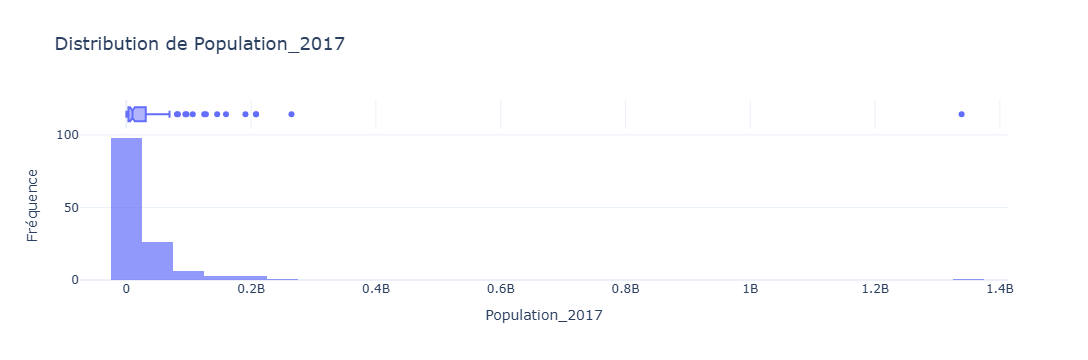

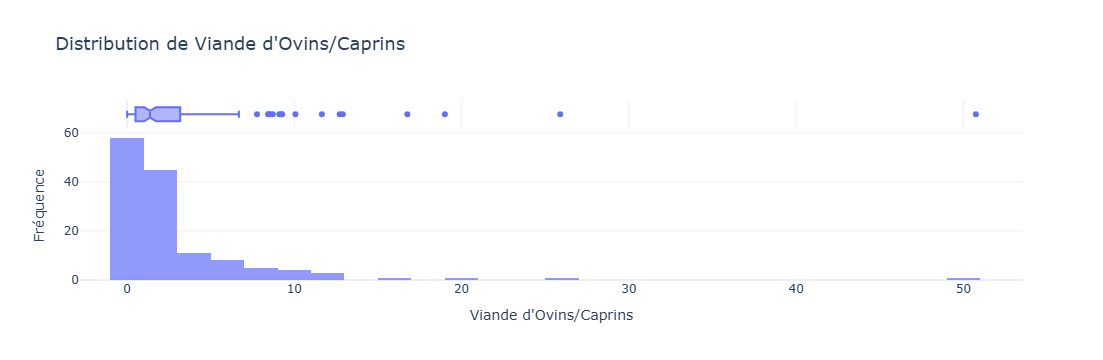

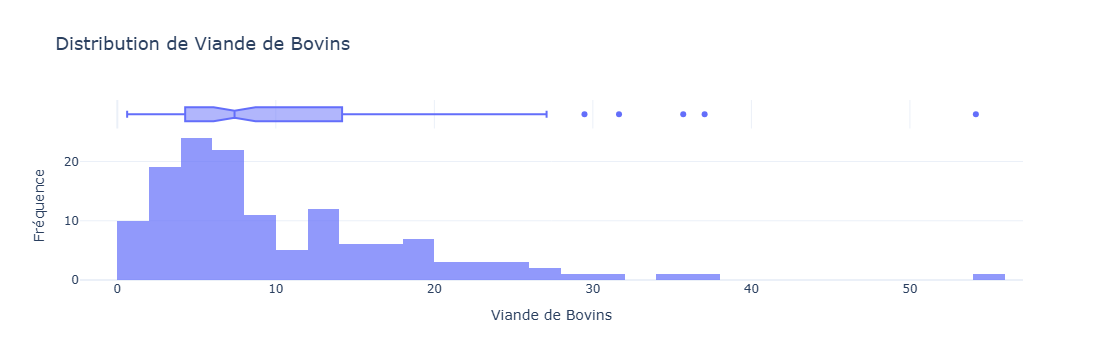

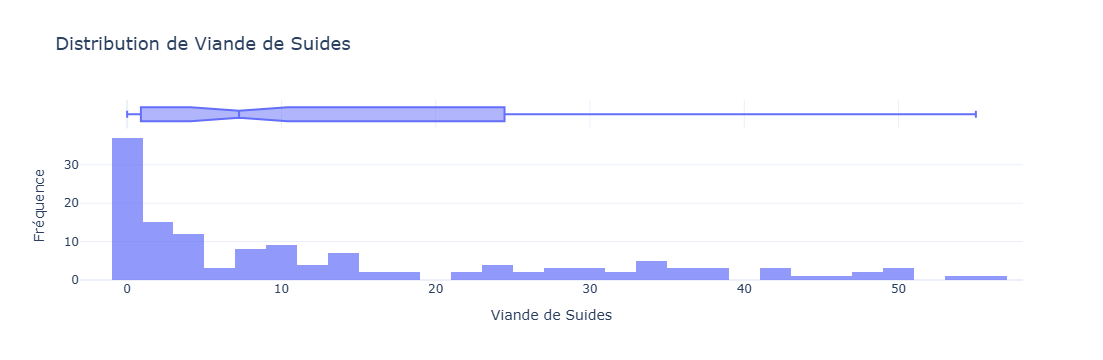

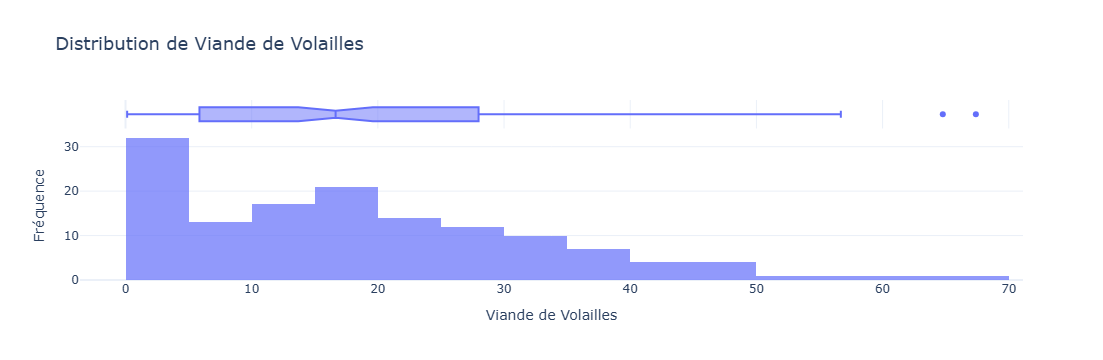

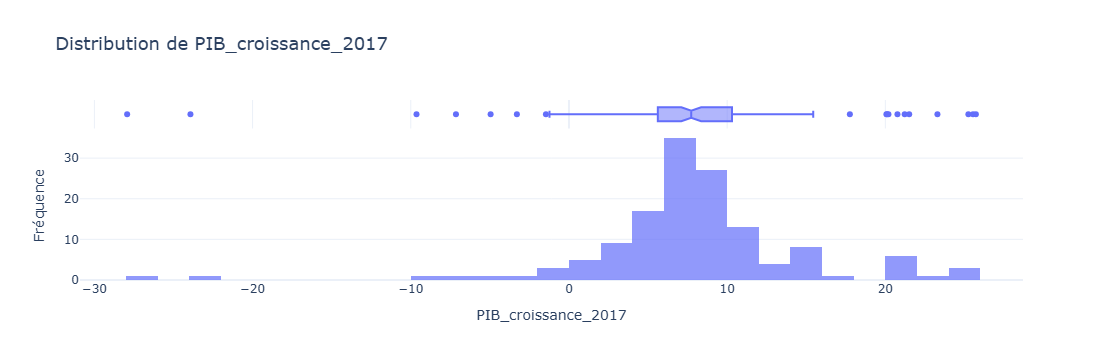

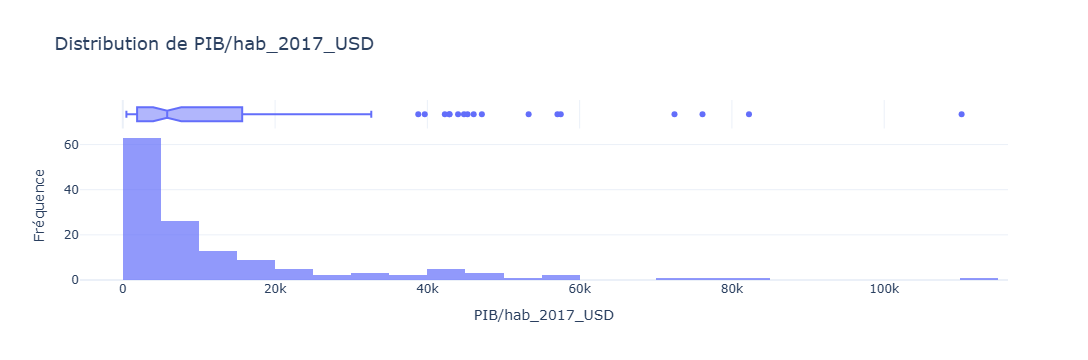

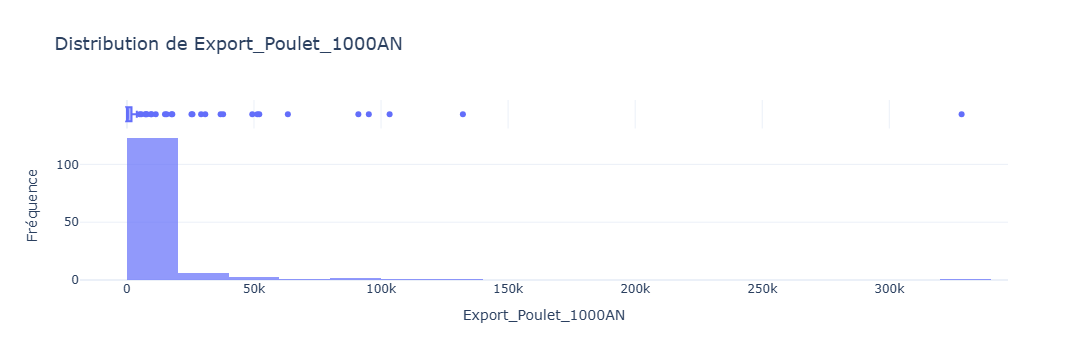

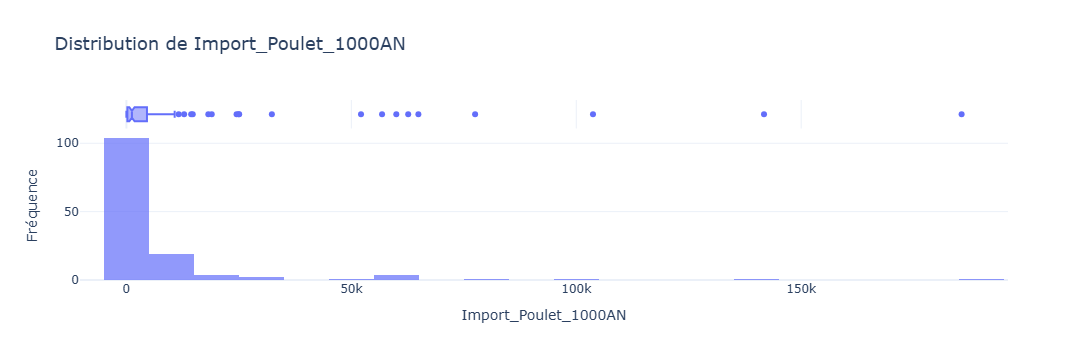

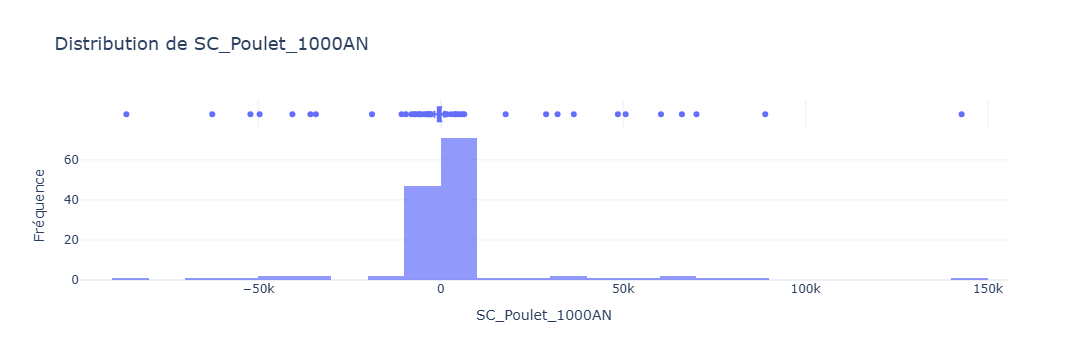

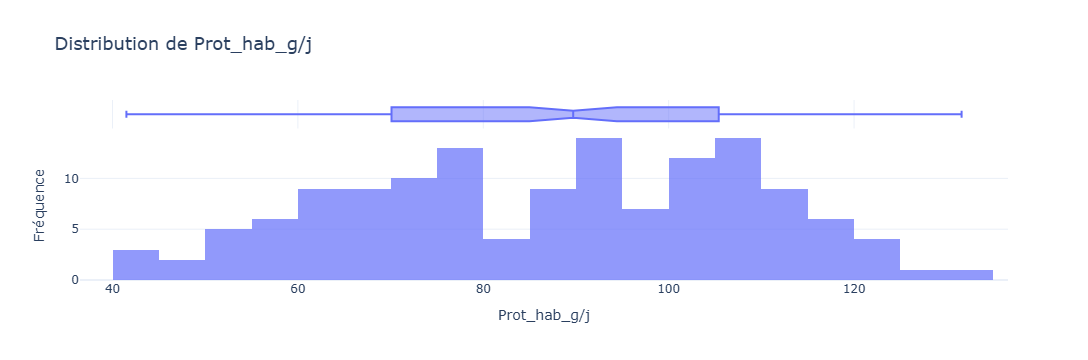

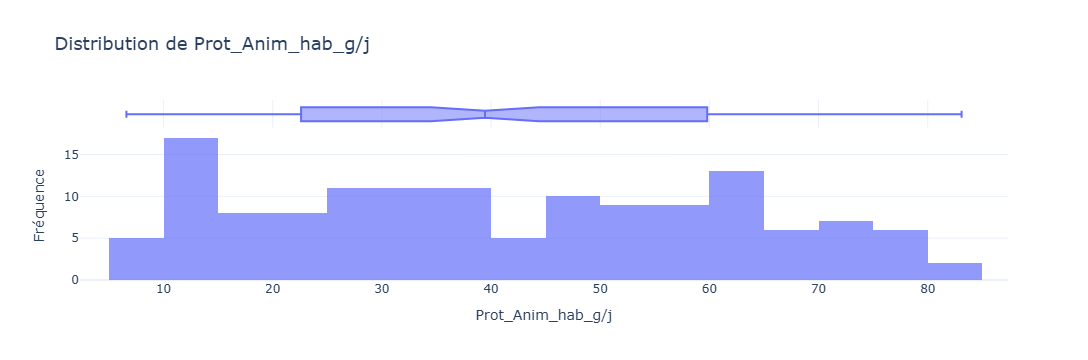

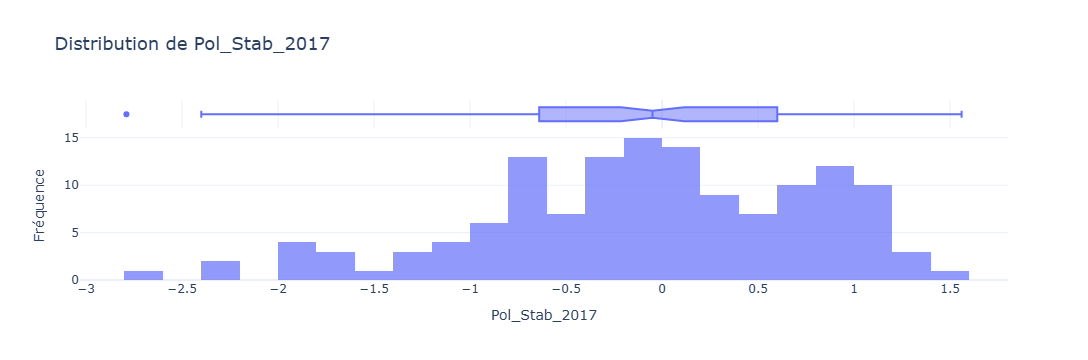

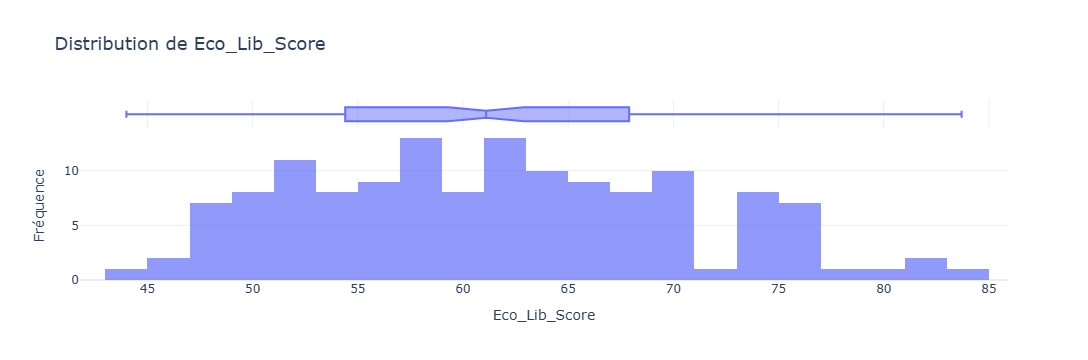

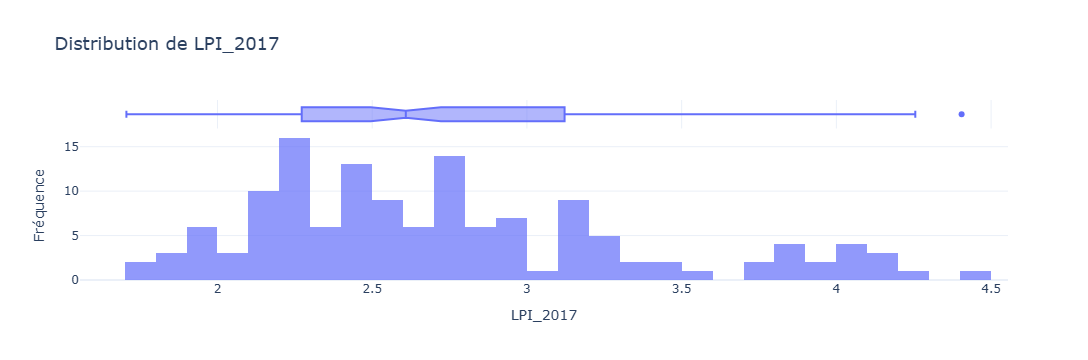

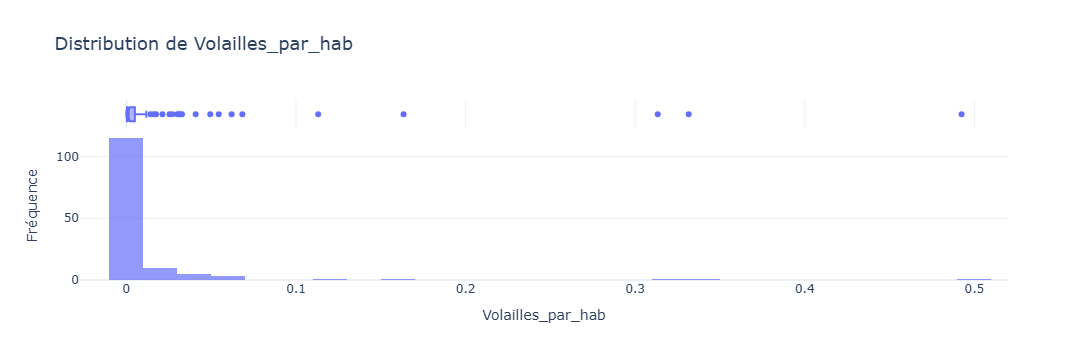

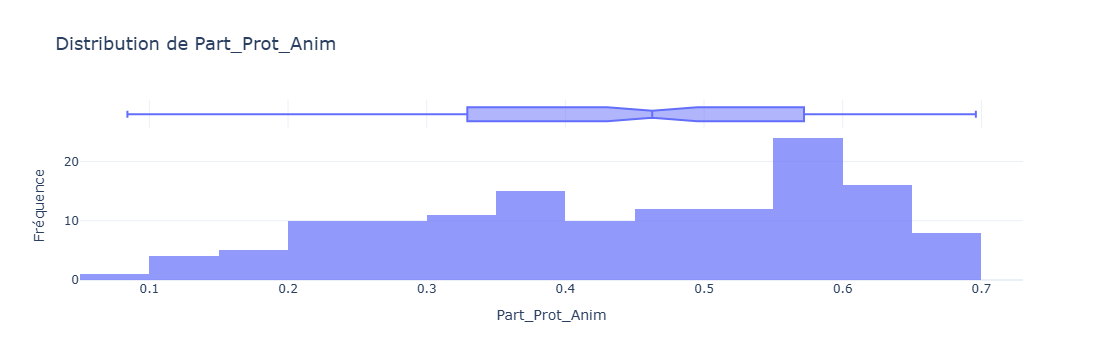

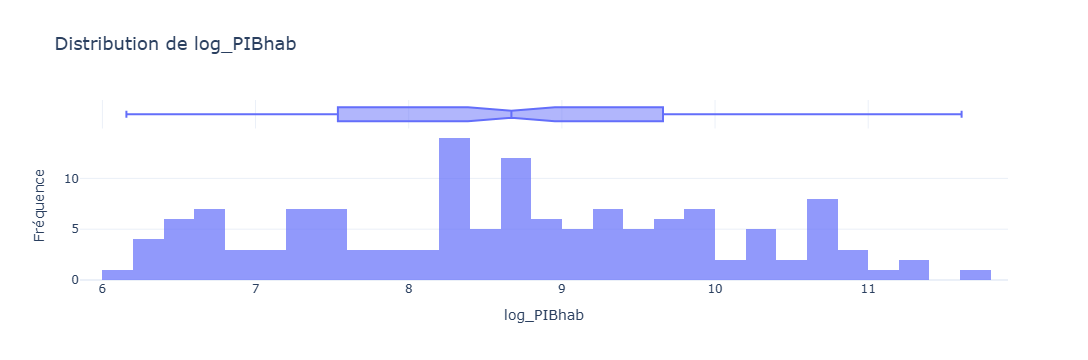

In [114]:
import plotly.express as px
import plotly.graph_objects as go

# Sélection des variables numériques
num_cols = df_lapoule.select_dtypes(include='float64').columns

# === Histogrammes interactifs avec Plotly ===
for col in num_cols:
    fig = px.histogram(
        df_lapoule,
        x=col,
        nbins=30,
        title=f"Distribution de {col}",
        marginal="box",  # ajoute un boxplot au-dessus
        opacity=0.7
    )
    fig.update_layout(
        title_font=dict(size=18),
        xaxis_title=col,
        yaxis_title="Fréquence",
        template="plotly_white"
    )
    fig.show()

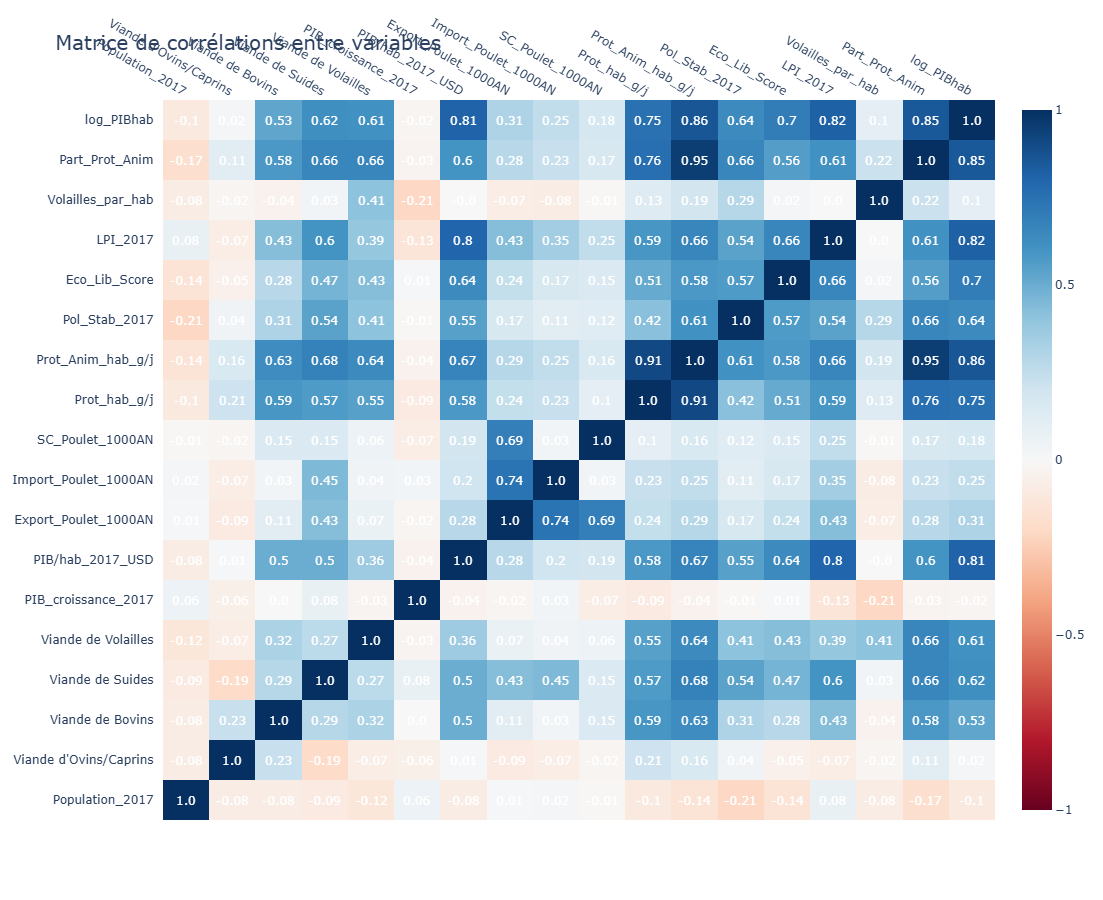

In [115]:
import numpy as np
import plotly.figure_factory as ff

# Calcul de la matrice de corrélation
corr_matrix = df_lapoule[num_cols].corr(method='pearson')

# === Heatmap interactive avec Plotly ===
fig = ff.create_annotated_heatmap(
    z=np.round(corr_matrix.values, 2),
    x=list(corr_matrix.columns),
    y=list(corr_matrix.index),
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    showscale=True,
    annotation_text=np.round(corr_matrix.values, 2)
)

fig.update_layout(
    title="Matrice de corrélations entre variables",
    title_font=dict(size=20),
    width=900,
    height=900,
    template="plotly_white"
)
fig.show()


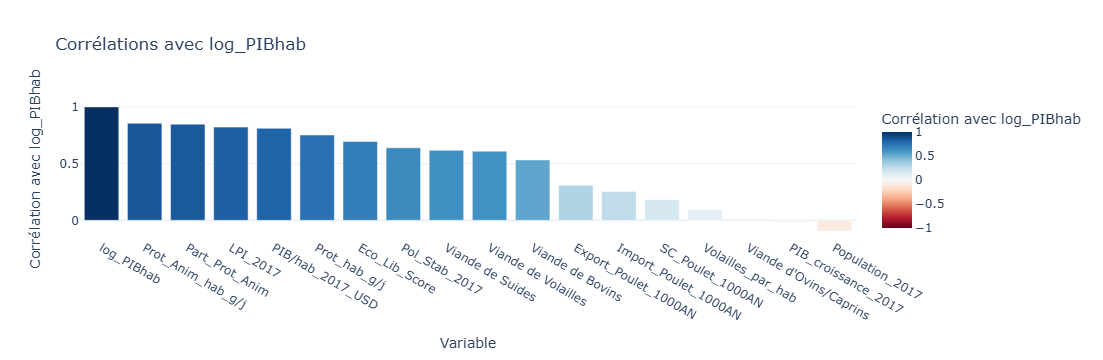

In [116]:
target = 'log_PIBhab'
corr_target = corr_matrix[target].sort_values(ascending=False).reset_index()
corr_target.columns = ['Variable', f'Corrélation avec {target}']

fig = px.bar(
    corr_target,
    x='Variable',
    y=f'Corrélation avec {target}',
    title=f"Corrélations avec {target}",
    color=f'Corrélation avec {target}',
    color_continuous_scale='RdBu',
    range_color=[-1,1]
)
fig.update_layout(xaxis={'categoryorder':'total descending'}, template="plotly_white")
fig.show()


<div style="background-color: #A30000; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Exporatation du dataset final</h2>
</div>

In [117]:
import os
os.makedirs("data", exist_ok=True)

# Sauvegarde dans un dossier (par exemple data/)
df_lapoule.to_csv("data/df_lapoule_clean.csv", index=False)
print("Dataset nettoyé exporté : data/df_lapoule_clean.csv")

Dataset nettoyé exporté : data/df_lapoule_clean.csv
